# API Tutorial of Event Related Potentials (ERPs) Simulation

This example demonstrates how to simulate an event-related potential (ERP) using the HNN Python API.

The workflow below recreates examples of the tactile evoked response as observed in Jones et al., J. Neuroscience 2007 [1] and as detailed in the [ERP Tutorial]() on our [HNN Textbook Website](https://jonescompneurolab.github.io/textbook/content/preface.html)


In [96]:
# Authors:
#   Mainak Jas <mmjas@mgh.harvard.edu>
#   Sam Neymotin <samnemo@gmail.com>
#   Blake Caldwell <blake_caldwell@brown.edu>
#   Christopher Bailey <cjb@cfin.au.dk>
#   Dylan Daniels <dylan_s_daniels@alumni.brown.edu>

# Getting Started with the HNN Python API

## Set Up Your HNN Environment

We assume for this section that you have access to the latest stable version of the `hnn-core` software.

If not, please follow the instructions on our [Installation page](https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html) to get started with the HNN Python API. 

Note that we provide instructions for running HNN "on the cloud" and for installing and running HNN on your local machine. 

While the cloud versions of HNN are relatively easy to get up and running, they come with certain limitations as described in the [Installation page](https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html). As such, we recommend that you install HNN on your local machine using the `conda` installation method to follow along with this and subsequent walkthroughs. 

The `conda` installation method will install the latest **stable** version of `hnn-core` on your machine, including the Graphical User Interface (GUI) and other dependencies for running faster simulations using parallelism.

Once you have completed the `conda` installation instructions, you can activate your conda environment with the following Command Line command:

```bash
conda activate hnn-core-env
```

### Following Along With the Textbook Tutorial


Note that any code blocks on the current or subsequent pages of the "Simulating ERPs" tutorial are **cumulative**. That is to say, these code blocks are meant to be run in sequential order, as they are drawn from a single `ipython` notebook file. 

By clicking the `Download Notebook` button at the top of this page, you can download the entire `.ipynb` file and run it interactively through Jupyter Notebook or through your preferred code editor (VS Code, Pycharm, etc.).

Note that your code editor may install additional dependencies needed to open and run `.ipynb` files in the `hnn-core-env` conda environment. 

However, if you would like to launch a Jupyter Notebook server directly from the Command Line, you will need to install Jupyter's `notebook` dependency directly into `hnn-core-env`. To do so, run the following command from your active `hnn-core-env` conda environment:

```bash
conda install -c conda-forge notebook
```

After installation, you can launch the jupyter server with the following command:

```bash
jupyter notebook
```

Alternatively, you can start an interactive ipython environment with the command below. This will allow you to run individual commands from your Command Line interface without needing to install the additional `notebook` dependency from Jupyter.  

```bash
ipython
```

## Import hnn_core and Visualize the Network

Now that you've set up your environment, we can finally start using HNN's Python API. The very first thing you'll want to do is import the `hnn_core` package

We'll also import one of the default models, `jones_2009_model`, which is the laminar SI model as originally presented in Jones et al., 2009.

In [97]:
import hnn_core  # noqa
from hnn_core import jones_2009_model

The HNN Python API is designed around the network object, which we will interact with to set parameters, run simulations, view simulation outputs, and more. 

We can create an instance of the default `jones_2009_model` by assigning it to a variable, such as net_default.

In [98]:
net_default = jones_2009_model()

We can then interact with the `network` object by using its available attributes

For example, the code block below will print the public-facing methods and data attributes that are available. For simplicity, we will only print the "public" attributes. There are additional "private" attributes that advanced users may want to interact with

In [99]:
# get all available attributes
attributes = dir(net_default)

# get the available *methods* (functions) that act on the network object
methods = [
    attr
    for attr in attributes
    # limit to attributes that *are* callable
    if callable(getattr(net_default, attr))
    and
    # exclude "private" attributes
    not attr.startswith("_")
]

# get the available *data attributes* that are associated with the
# network object
data_attributes = [
    attr
    for attr in attributes
    # limit to attributes that *are not* callable
    if not callable(getattr(net_default, attr))
    and
    # exclude "private" attributes
    not attr.startswith("_")
]

# print public methods
print("Methods:")
print(*methods, sep=", ")

# print public data attributes
print("\nData attributes:")
print(*data_attributes, sep=", ")

Methods:
add_bursty_drive, add_connection, add_electrode_array, add_evoked_drive, add_poisson_drive, add_spike_train_drive, add_tonic_bias, clear_connectivity, clear_drives, copy, filter_cell_types, get_global_synaptic_gains, gid_to_type, plot_cells, set_cell_positions, set_global_synaptic_gains, to_dict, write_configuration

Data attributes:
cell_response, cell_types, connectivity, delay, external_biases, external_drives, gid_ranges, pos_dict, rec_arrays, threshold


We can then use these attributes with the network object we instantiated previously

First, let's try examining one of the network's data attributes: `cell_types`. We can check the object's `type` so we know how to interact with it

In [100]:
# check the `net.cell_types` object's type
print(f"Object type: {type(net_default.cell_types)}")

Object type: <class 'dict'>


Now that we have confirmed the `net.cell_types` object is a dictionary, we know how to ineract with it using native Python code

Next, let's print the dictionary's keys, which in this case will tell us the unique cell types in the network

In [101]:
print("Cell types:")

# loop through the dictionary keys and print them
for key in net_default.cell_types.keys():
    print(f"    {key}")

Cell types:
    L2_basket
    L2_pyramidal
    L5_basket
    L5_pyramidal


Let's examine one of these `cell_types` objects in more detail. We'll use "L5_pyramidal" as an example, and we'll assign it a variable for easier access

In [102]:
# assign net_default.cell_types["L5_pyramidal"] to a variable
l5_pyr_celltype = net_default.cell_types["L5_pyramidal"]

# check its type
print(type(l5_pyr_celltype))

<class 'dict'>


Once again, we have a dictionary. We can loop through it and print the dictionary keys and values to better understand the object's data structure

In [103]:
for key, value in l5_pyr_celltype.items():
    print(f'Key: "{key}"')
    print("Value:")
    print(f"   Type:  {type(value)}")
    print(f"   Value: {value}")
    print("\n" + "-"*20 + "\n")


Key: "cell_object"
Value:
   Type:  <class 'hnn_core.cell.Cell'>
   Value: <Cell | gid=None>

--------------------

Key: "cell_metadata"
Value:
   Type:  <class 'dict'>
   Value: {'morpho_type': 'pyramidal', 'electro_type': 'excitatory', 'layer': '5', 'measure_dipole': True, 'reference': 'https://doi.org/10.7554/eLife.51214'}

--------------------



We can see that this yields another dictionary with two keys. The first is "cell_object", which contains a class called `hnn_core.cell.Cell`. We will explore this class further in upcoming sections

The second is "cell_metadata", which contains a dictionary with information about the "L5_pyramidal" cell type. 

Next, let's try using one of the network's **methods**: `plot_cells()`. This will plot a diagram of the network that shows all of the cell types in a 3D grid

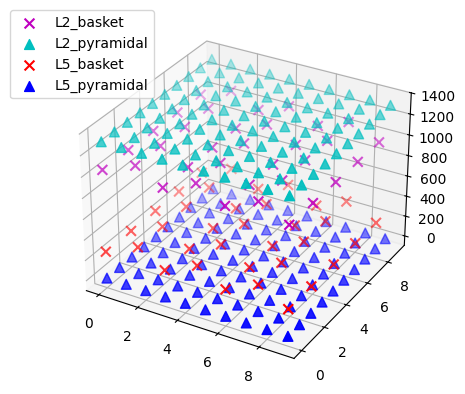

In [104]:
# we can plot a diagram of the network using the .plot_cells() method
_ = net_default.plot_cells()

The `hnn_core.cell.Cell` class also contains its own set of methods and data attributes. For example, we can plot the morphology of the "L5_pyramidal" cell using the `.plot_morphology()` method

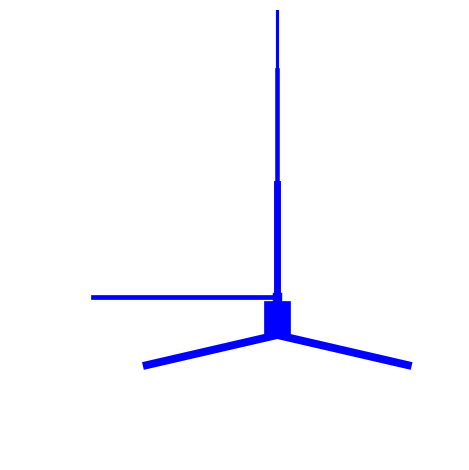

In [105]:
# using the variable we created above, we can access the `Cell` class
# object and plot its morphology

# remember: l5_pyr_celltype is a dictionary, so we need to use the
# "cell_object" key to access the `Cell` class for plotting

_ = l5_pyr_celltype["cell_object"].plot_morphology()

# Section

In [106]:
# Code block